# Gene Expression PTR analysis
March 21, 2024

Simple PTR analysis to compare deconvolved PTR to raw PTR.

Then compare deconvolved PTR to gene expression deconvovled PTR.


In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [168]:
from cc_src.peak_to_trough_anaysis import load_deconvolved_ge_ptrs

outdir = 'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/'

deconvolved_ge_ptrs = load_deconvolved_ge_ptrs(outdir)

In [157]:
deconvolved_ge_ptrs.head()

,gene,ptr
orf_name,,
YAL067W-A,YAL067W-A,1.0021
YAL067C,SEO1,1.8564
YAL064C-A,YAL064C-A,1.0013
YAL064W,YAL064W,1.0018
YAL063C-A,YAL063C-A,1.002


In [160]:
# Now get the PTR for the raw gene expression data
from src.config import read_yl_vst_data_rep, load_yl_rg1_vst_config
from src.model import Model

def load_raw_ge_ptrs(replicate):
    config = load_yl_rg1_vst_config(replicate)
    model = Model(config, "SEO1")

    mu0 = config.intervals_wt1[0][0]
    rep1_vst_ge_data = read_yl_vst_data_rep(replicate)

    from cc_src.peak_to_trough import compute_quantile_ptr

    # Compute the peak to trough ratio for non recovery timepoints
    non_RG1_G = rep1_vst_ge_data[rep1_vst_ge_data.columns[rep1_vst_ge_data.columns > mu0]]
    g_ptrs = np.apply_along_axis(lambda mat: compute_quantile_ptr(mat, 
       0.2, 0.8), 1, non_RG1_G)
    rep1_raw_ptrs = rep1_vst_ge_data[[]].copy()
    rep1_raw_ptrs['g_ptr'] = g_ptrs

    return rep1_raw_ptrs


In [162]:
rep1_raw_ptrs = load_raw_ge_ptrs(1)
rep1_raw_ptrs.head(2)

,g_ptr
orf_name,
YAL068C,1.065611
YAL067W-A,1.000000


In [163]:
joined_ptr_comparison = rep1_raw_ptrs.join(geneset).dropna()

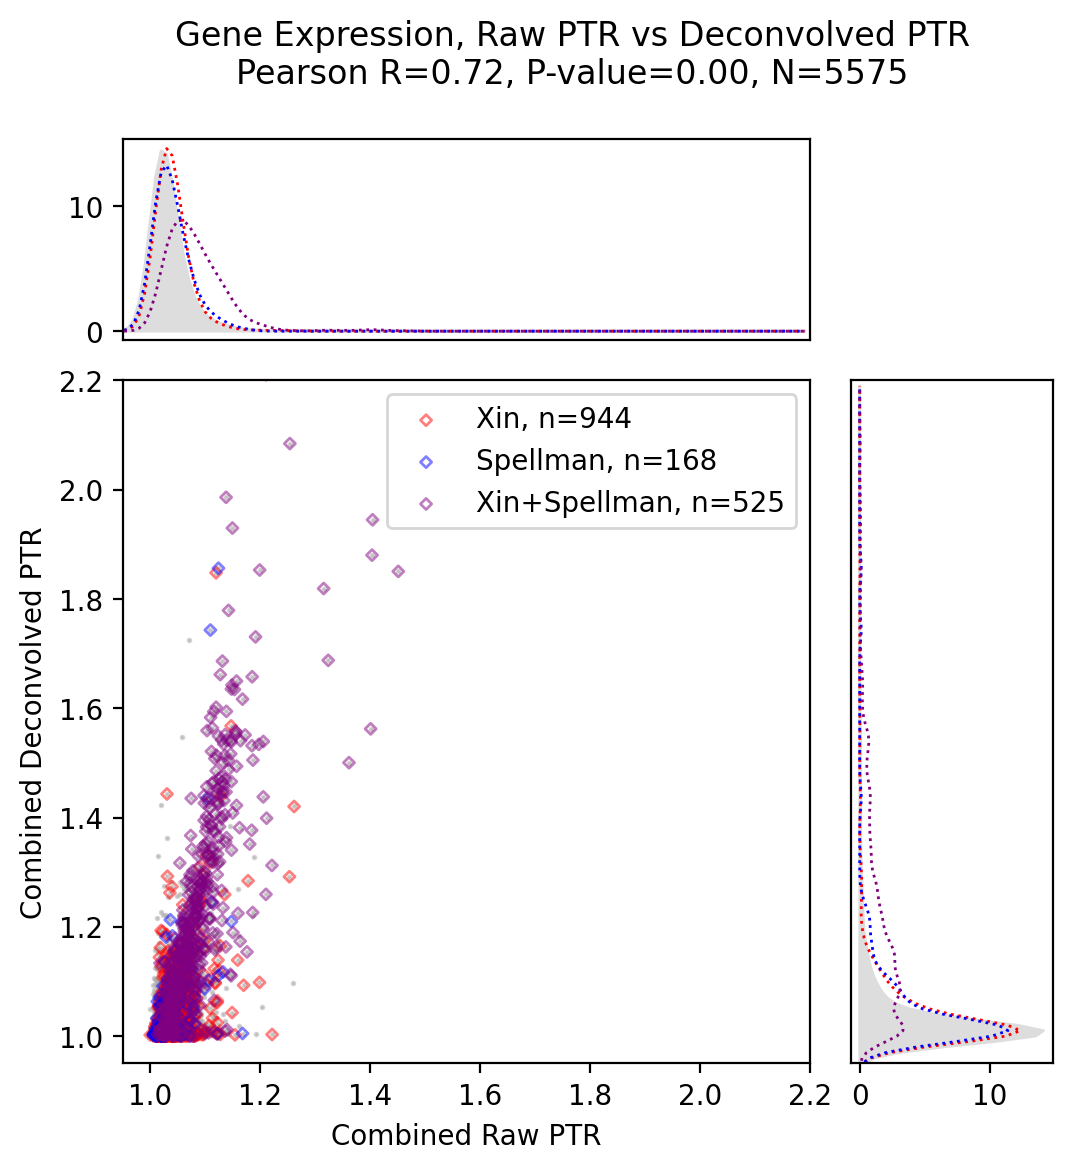

In [172]:
from cc_src.peak_to_trough_anaysis import plot_comparison_scatter, filter_index, \
    plot_comparison_ptr, create_highlighted_orfs_array

x, y = joined_ptr_comparison.g_ptr, joined_ptr_comparison.ptr

highlighted_orfs = create_highlighted_orfs_array(joined_ptr_comparison)

plot_comparison_ptr(x, y, highlighted_orfs, xlim=(0.95, 2.2), ylim=(0.95, 2.2),
                   title="Gene Expression, Raw PTR vs Deconvolved PTR",
                   xlabel="Combined Raw PTR",
                   ylabel="Combined Deconvolved PTR",
                   bw=(0.02, 0.02))


In [85]:
# Compare GE to xin ge ptrs next, "should" be similar, but may be a bit different. 
# the marginals should be clear for sanity checking

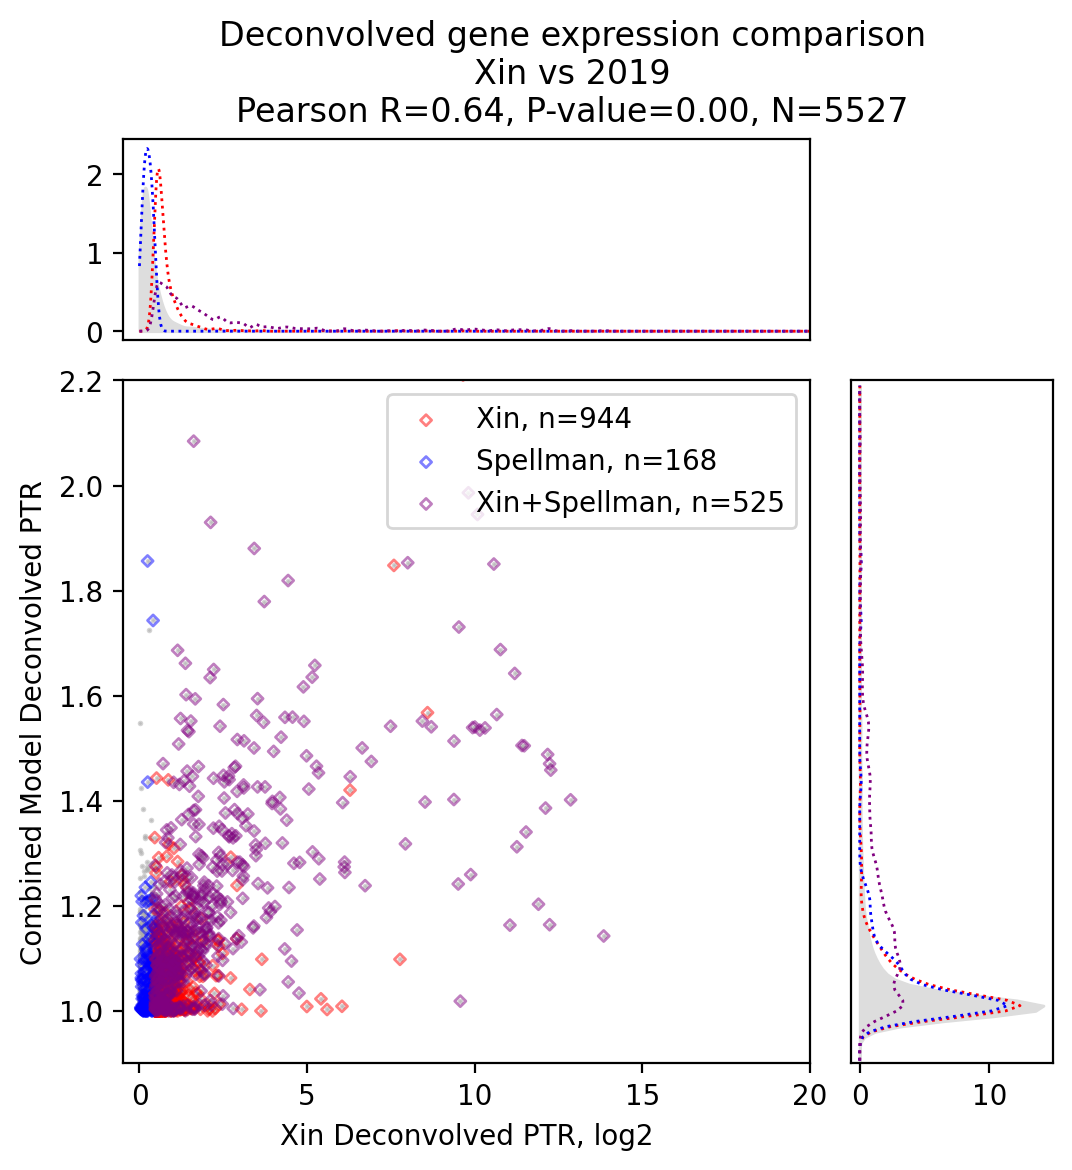

In [171]:

def load_xin_ptrs():
    gene_as = pd.read_csv('datasets/datasets_from_web_deconvolution.cs.duke.edu/gene_associated.tsv', 
                          sep='\t')
    xin_ptrs_df = gene_as.set_index('Systematic Name')[['Deconvolved PTR (80pt/20pt)']].rename(
    columns={'Deconvolved PTR (80pt/20pt)': 'xin_ptr'})
    return xin_ptrs_df

xin_ptrs_df = load_xin_ptrs()

ptrs_compared_xin_df = xin_ptrs_df.join(joined_ptr_comparison)
ptrs_compared_xin_df = ptrs_compared_xin_df.dropna()

x, y = ptrs_compared_xin_df.xin_ptr, ptrs_compared_xin_df.ptr
x = np.log2(x)

highlighted_orfs = create_highlighted_orfs_array(ptrs_compared_xin_df)

plot_comparison_ptr(x, y, highlighted_orfs, xlim=(-0.5, 20), ylim=(0.9, 2.2), bw=(0.1, 0.02), 
                   title="Deconvolved gene expression comparison\nXin vs 2019",
                   xlabel="Xin Deconvolved PTR, log2",
                   ylabel="Combined Model Deconvolved PTR")
